## Bell States Tutorial

#### Introduction to Bell States

Bell states are the four maximally entangled two-qubit quantum states that form the foundation of quantum entanglement and quantum information protocols. They were introduced by physicist John Stewart Bell and are fundamental to understanding quantum mechanics.

#### The Four Bell States

1. **|Ψ+⟩ = (|00⟩ + |11⟩)/√2** - Both qubits always give the same measurement outcome
2. **|Ψ-⟩ = (|00⟩ - |11⟩)/√2** - Same outcomes with phase difference
3. **|Φ+⟩ = (|01⟩ + |10⟩)/√2** - Qubits always give opposite outcomes  
4. **|Φ-⟩ = (|01⟩ - |10⟩)/√2** - Opposite outcomes with phase difference

This tutorial will guide you through creating, executing, and analyzing all four Bell states using the QpiAI Quantum SDK.

## Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [ ]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

## Part 1: Creating a Single Bell State

Let's start with the most common Bell state: **|Ψ+⟩**

This state creates perfect correlation: both qubits will always measure the same value (either both 0 or both 1).

### Circuit Construction

The circuit consists of:
1. **Hadamard (H) gate** on qubit 0: Creates superposition (|0⟩ + |1⟩)/√2
2. **CNOT gate**: Entangles qubit 0 (control) with qubit 1 (target)

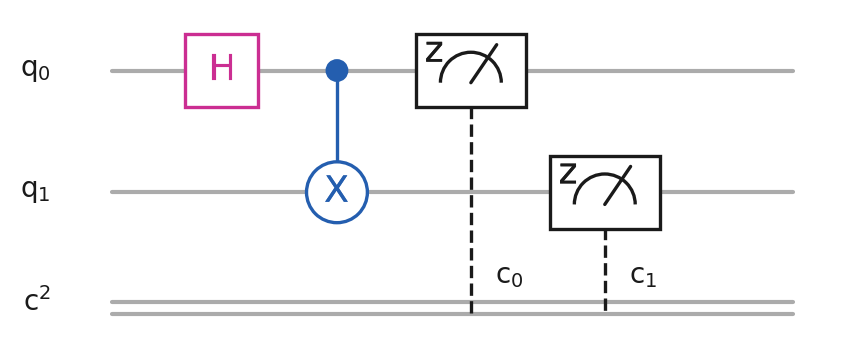

In [2]:
import numpy as np
from qpiai_quantum.state_preparation import BellStateGenerator

bell = BellStateGenerator(state_type='|Ψ+>')
circuit = bell.build_circuit(measure=True)
circuit.show()


### Executing the Circuit on QpiAI Quantum Hardware

Now we'll execute the circuit and analyze the results:

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [3]:
shots = 10000
# Note: experiment_name is only required for cloud executions
result = circuit.run(shots=shots, device_name="QpiAI-QSV-Local")
print(f"Counts : {result.get_counts()}")

Counts : {'00': 4976, '11': 5024}


### Visualize Results as Histogram

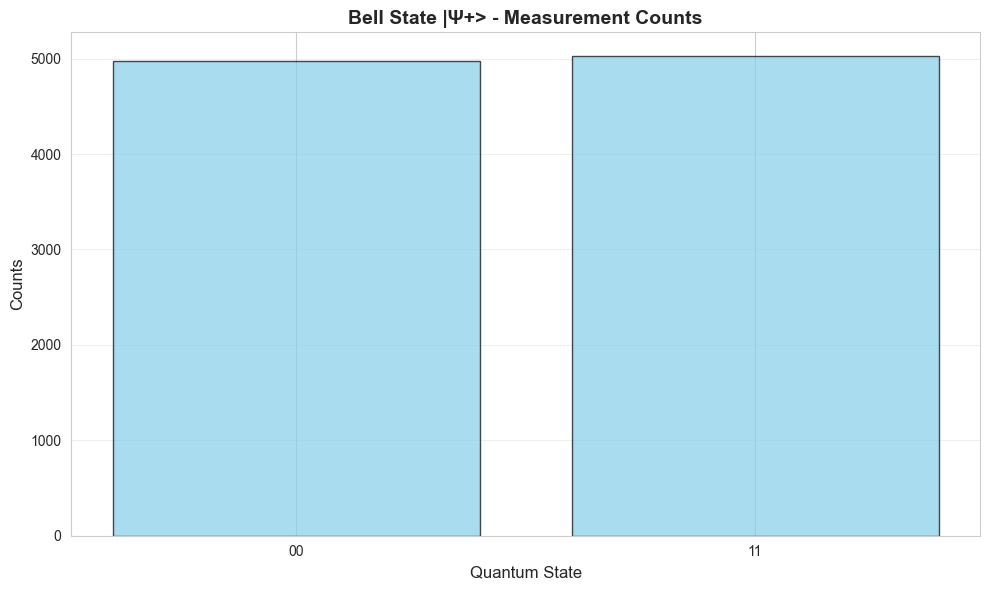

In [4]:
bell.visualize('histogram', result=result)

### Get Expected Outcomes

Check the theoretical probability distribution for this Bell state:

In [5]:
expected = bell.get_expected_outcomes()
print(f"Expected outcomes: {expected}")

Expected outcomes: {'00': 0.5, '11': 0.5}


## Part 2: Exploring All Four Bell States

Now let's explore all four Bell states individually to understand their unique properties.

### Create All Four Bell States

In [6]:
all_bells = BellStateGenerator.get_all_bell_states()

for state_name, generator in all_bells.items():
    print(f"\n{state_name}:")
    print(f"  {generator.description}")


|Ψ+>:
  Bell state |Ψ+⟩ = (|00⟩ + |11⟩)/√2 - Both qubits always same

|Ψ->:
  Bell state |Ψ-⟩ = (|00⟩ - |11⟩)/√2 - Same with phase flip

|Φ+>:
  Bell state |Φ+⟩ = (|01⟩ + |10⟩)/√2 - Qubits always opposite

|Φ->:
  Bell state |Φ-⟩ = (|01⟩ - |10⟩)/√2 - Opposite with phase flip


### Visualize Circuit Diagrams for All States


Circuit for |Ψ+>


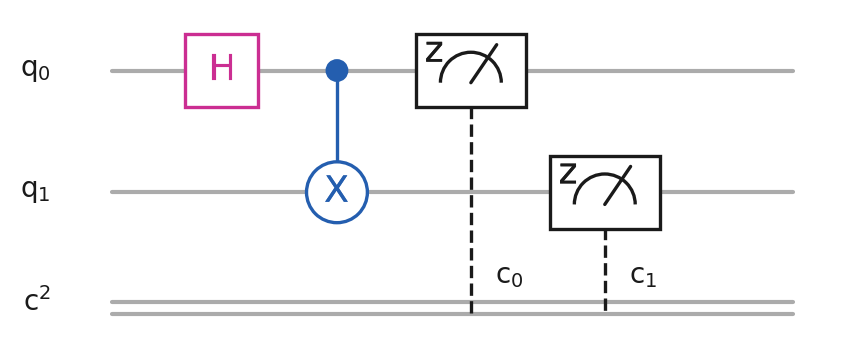


Circuit for |Ψ->


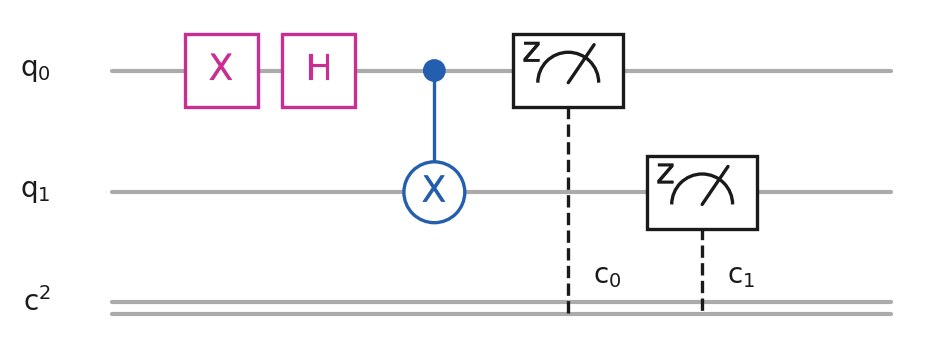


Circuit for |Φ+>


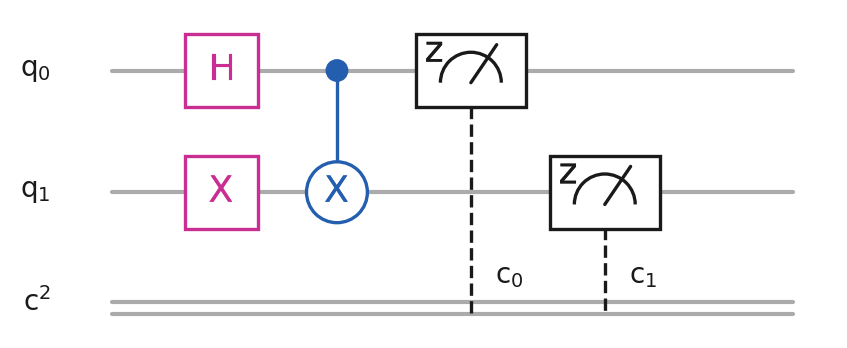


Circuit for |Φ->


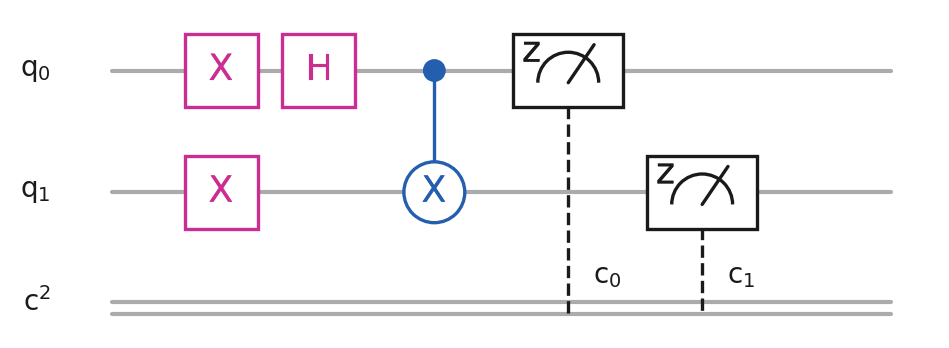

In [7]:
# Build and display circuits for each Bell state
for state_name, generator in all_bells.items():
    print(f"\n{'='*50}")
    print(f"Circuit for {state_name}")
    print(f"{'='*50}")
    circuit = generator.build_circuit(measure=True)
    circuit.show()

### Expected Outcomes for Each Bell State

In [8]:
print("Expected probability distributions for each Bell state:\n")
for state_name, generator in all_bells.items():
    expected = generator.get_expected_outcomes()
    print(f"{state_name}: {expected}")

Expected probability distributions for each Bell state:

|Ψ+>: {'00': 0.5, '11': 0.5}
|Ψ->: {'00': 0.5, '11': 0.5}
|Φ+>: {'01': 0.5, '10': 0.5}
|Φ->: {'01': 0.5, '10': 0.5}


## Summary and Key Takeaways

In this tutorial, we've comprehensively explored:

1. **Bell State Fundamentals**: Understanding the four maximally entangled states
2. **Circuit Construction**: How to build Bell state circuits using quantum gates
3. **Execution**: Running Bell states on quantum hardware and simulators
4. **Comparison**: Analyzing all four Bell states simultaneously
5. **Advanced Features**: Convenience functions and customizable parameters

### Key Methods Reference

- `BellStateGenerator(state_type)` - Create a Bell state generator
- `build_circuit(measure=True)` - Build the quantum circuit
- `run(shots, backend)` - Execute on quantum backend (Note: `experiment_name` is optional and only required for cloud executions)
- `get_expected_outcomes()` - Get theoretical probability distribution
- `visualize(plot_type, result)` - Create visualizations
- `get_all_bell_states()` - Get all four Bell state generators
- `compare_all_bell_states(shots, backend)` - Compare all states at once

---

**Thank you for learning with QpiAI!**

In [9]:
import qpiai_quantum
print(qpiai_quantum.__version__)

0.1.32
